In [ ]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)
print(tf.config.list_physical_devices())

2.21.0
2.4.3
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
# =========================
# 1. IMPORTS
# =========================
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks, layers, models

# AUTOTUNE for tf.data (defined early so functions can use it)
AUTOTUNE = tf.data.AUTOTUNE
# Speed-up on GPU when available
if tf.config.list_physical_devices("GPU"):
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled")
else:
    print("Running on CPU")

Running on CPU


In [ ]:
# =========================
# 2. LOAD DATASET (RAW SPLIT FOR MULTI-MODEL TRAINING)
# =========================
DATASET_PATH = Path(
    r"C:\Users\deept\Fpxnet Dropbox\xafolo xafolo\shareit\course\Deepu\tea project\advanced images"
)

SEED = 123
VAL_SPLIT = 0.2

# Fixed class order requested by user
class_names = [
    "green_tea",
    "black_tea",
    "oolong_tea",
    "chamomile_tea",
    "peppermint_tea",
    "ginger_tea",
    "hibiscus_tea",
    "rooibos_tea",
    "lavender_tea",
    "matcha_tea",
    "chai_tea",
    "turmeric_tea",
    "rosehip_tea",
    "blueberry_tea",
    "raspberry_tea",
    "kukicha_tea",
    "genmaicha_tea",
    "lemon_tea",
]
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

missing_classes = [c for c in class_names if not (DATASET_PATH / c).is_dir()]
if missing_classes:
    raise ValueError(f"Missing class folders: {missing_classes}")

print("Using classes:", class_names)
print("Num classes:", len(class_names))

# Gather all image paths and labels
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
file_paths = []
labels = []
for cname in class_names:
    class_dir = DATASET_PATH / cname
    class_files = [
        p
        for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    ]
    file_paths.extend([str(p) for p in class_files])
    labels.extend([class_to_idx[cname]] * len(class_files))

file_paths = np.array(file_paths)
labels = np.array(labels, dtype=np.int32)

if len(file_paths) == 0:
    raise ValueError("No images found. Check DATASET_PATH and class folders.")

# Stratified split guarantees class representation in validation set
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths,
    labels,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=labels,
)


def load_raw_image(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)


raw_train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
raw_train_ds = raw_train_ds.shuffle(
    len(train_paths), seed=SEED, reshuffle_each_iteration=True
)
raw_train_ds = raw_train_ds.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)

raw_val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
raw_val_ds = raw_val_ds.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)

# Quick sanity check: every class should appear in validation
val_counts = np.bincount(val_labels, minlength=len(class_names))
coverage_df = pd.DataFrame(
    {
        "class": class_names,
        "val_count": val_counts,
    }
)
print("Validation coverage by class:")
display(coverage_df)

Using classes: ['green_tea', 'black_tea', 'oolong_tea', 'chamomile_tea', 'peppermint_tea', 'ginger_tea', 'hibiscus_tea', 'rooibos_tea', 'lavender_tea', 'matcha_tea', 'chai_tea', 'turmeric_tea', 'rosehip_tea', 'blueberry_tea', 'raspberry_tea', 'kukicha_tea', 'genmaicha_tea', 'lemon_tea']
Num classes: 18
Validation coverage by class:


,class,val_count
0,green_tea,60
1,black_tea,60
2,oolong_tea,60
3,chamomile_tea,60
4,peppermint_tea,60
5,ginger_tea,60
6,hibiscus_tea,60
7,rooibos_tea,60
8,lavender_tea,60
9,matcha_tea,60


In [ ]:
# =========================
# 3. SAVE CLASS INFO
# =========================
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['green_tea', 'black_tea', 'oolong_tea', 'chamomile_tea', 'peppermint_tea', 'ginger_tea', 'hibiscus_tea', 'rooibos_tea', 'lavender_tea', 'matcha_tea', 'chai_tea', 'turmeric_tea', 'rosehip_tea', 'blueberry_tea', 'raspberry_tea', 'kukicha_tea', 'genmaicha_tea', 'lemon_tea']


In [ ]:
def make_dataset(paths, labels, spec, training=True):
    preprocess_input = resolve_preprocess(spec["resolved_backbone"])

    def preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, spec["img_size"])
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, tf.cast(label, tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(
            min(len(paths), 1000), seed=SEED, reshuffle_each_iteration=False
        )
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(spec["batch_size"])
    ds = ds.prefetch(buffer_size=spec["prefetch"])
    return ds

In [ ]:
# =========================
# 5. DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.12),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.2),
    ]
)

In [ ]:
# =========================
# 4. DEFINE HELPER FUNCTIONS AND TRAIN_ONE_MODEL
# =========================
AUTOTUNE = tf.data.AUTOTUNE


def resolve_preprocess(backbone_name):
    """Get preprocessing function for backbone model."""
    if (
        "EfficientNetV2S" in backbone_name
        or "efficientnet_v2_s" in backbone_name.lower()
    ):
        return tf.keras.applications.efficientnet_v2.preprocess_input
    elif (
        "MobileNetV3Small" in backbone_name
        or "mobilenetv3small" in backbone_name.lower()
    ):
        return tf.keras.applications.mobilenet_v3.preprocess_input
    else:
        return lambda x: x / 255.0


def build_backbone(backbone_name, img_size, num_classes):
    """Build backbone model."""
    if "EfficientNetV2S" in backbone_name:
        backbone = tf.keras.applications.EfficientNetV2S(
            input_shape=(*img_size, 3), include_top=False, weights="imagenet"
        )
    elif "MobileNetV3Small" in backbone_name:
        backbone = tf.keras.applications.MobileNetV3Small(
            input_shape=(*img_size, 3), include_top=False, weights="imagenet"
        )
    else:
        raise ValueError(
            f"Unknown backbone: {backbone_name}. Supported: EfficientNetV2S, MobileNetV3Small"
        )
    return backbone


def train_one_model(spec):
    """Train a single model with the given spec."""
    print(f"\n{'='*60}")
    print(f"Training: {spec['name']}")
    print(f"Backbone: {spec['resolved_backbone']}")
    print(f"Image size: {spec['img_size']}, Batch size: {spec['batch_size']}")
    print(f"{'='*60}")

    augmentation = tf.keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.12),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.2),
        ]
    )

    # Create datasets
    train_ds = make_dataset(train_paths, train_labels, spec, training=True)
    val_ds = make_dataset(val_paths, val_labels, spec, training=False)

    # Build model
    backbone = build_backbone(spec["resolved_backbone"], spec["img_size"], num_classes)
    backbone.trainable = False

    model = models.Sequential(
        [
            layers.Input(shape=(*spec["img_size"], 3)),
            augmentation,
            backbone,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(spec["dropout"]),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    # Callbacks
    save_dir = Path("tea_training_state") / spec["name"]
    save_dir.mkdir(parents=True, exist_ok=True)

    callbacks_list = [
        callbacks.EarlyStopping(
            monitor="val_accuracy", patience=4, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
        ),
        callbacks.ModelCheckpoint(
            str(save_dir / "tea_model_best.keras"),
            monitor="val_accuracy",
            save_best_only=True,
        ),
    ]

    # Phase 1: Train head only
    print("\nPhase 1: Training head (backbone frozen)...")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=spec["initial_lr"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=spec["epochs_head"],
        callbacks=callbacks_list,
        class_weight=class_weight,
    )

    # Phase 2: Fine-tune
    if spec["epochs_finetune"] > 0:
        print("\nPhase 2: Fine-tuning (unfreezing last layers)...")
        for layer in backbone.layers[-spec["unfreeze_last"] :]:
            layer.trainable = True

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=spec["finetune_lr"]),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
        fine_tune_history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=spec["epochs_finetune"],
            callbacks=callbacks_list,
            class_weight=class_weight,
        )
    else:
        fine_tune_history = None

    # Save final model
    final_model_path = save_dir / "tea_model_final.keras"
    model.save(final_model_path)

    # Save state
    state = {
        "best_model_path": str(save_dir / "tea_model_best.keras"),
        "final_model_path": str(final_model_path),
        "model_name": spec["name"],
        "resolved_backbone": spec["resolved_backbone"],
        "img_size": spec["img_size"],
        "batch_size": spec["batch_size"],
        "history": history.history,
        "fine_tune_history": fine_tune_history.history if fine_tune_history else {},
    }

    # Save analysis state
    analysis_state = {
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "num_classes": num_classes,
        "seed": SEED,
        "val_split": VAL_SPLIT,
        "train_paths": train_paths,
        "val_paths": val_paths,
        "train_labels": train_labels,
        "val_labels": val_labels,
        "img_size": list(spec["img_size"]),
        "batch_size": spec["batch_size"],
        "model_name": spec["name"],
        "backbone": spec["resolved_backbone"],
        "resolved_backbone": spec["resolved_backbone"],
        "requested_backbone": spec["requested_backbone"],
        "history": history.history,
        "fine_tune_history": fine_tune_history.history if fine_tune_history else {},
        "initial_lr": spec["initial_lr"],
        "finetune_lr": spec["finetune_lr"],
        "epochs_head": spec["epochs_head"],
        "epochs_finetune": spec["epochs_finetune"],
        "unfreeze_last": spec["unfreeze_last"],
        "best_model_path": str(save_dir / "tea_model_best.keras"),
        "final_model_path": str(final_model_path),
        "class_counts": class_counts,
        "class_weight": class_weight,
    }

    joblib.dump(analysis_state, save_dir / "analysis_state.joblib", compress=3)

    print(f"\n✓ Training complete for {spec['name']}")
    print(f"  Best model: {state['best_model_path']}")
    print(f"  Final model: {state['final_model_path']}")

    return state


# =========================
# 4B. CLASS WEIGHTS & MODEL SPECS
# =========================
class_counts = np.bincount(train_labels, minlength=num_classes)
class_weight = {
    i: len(train_labels) / (num_classes * count)
    for i, count in enumerate(class_counts)
    if count > 0
}

In [ ]:
MODEL_SPECS = [
    {
        "name": "efficientnet_v2_s",
        "requested_backbone": "EfficientNetV2S",
        "backbone_candidates": ["EfficientNetV2S"],
        "resolved_backbone": "EfficientNetV2S",
        "img_size": (320, 320),
        "batch_size": 64,
        "dropout": 0.3,
        "prefetch": AUTOTUNE,
        "initial_lr": 1e-3,
        "finetune_lr": 1e-5,
        "epochs_head": 5,
        "epochs_finetune": 2,
        "unfreeze_last": 30,
    },
    {
        "name": "mobilenetv3_small",
        "requested_backbone": "MobileNetV3Small",
        "backbone_candidates": ["MobileNetV3Small"],
        "resolved_backbone": "MobileNetV3Small",
        "img_size": (224, 224),
        "batch_size": 128,
        "dropout": 0.2,
        "prefetch": AUTOTUNE,
        "initial_lr": 1e-3,
        "finetune_lr": 1e-5,
        "epochs_head": 5,
        "epochs_finetune": 2,
        "unfreeze_last": 15,
    },
]

In [ ]:
# =========================
# 5. TRAIN BOTH MODELS SEPARATELY
# =========================
run_results = {}
for spec in MODEL_SPECS:
    run_results[spec["name"]] = train_one_model(spec)

print("\nTraining complete for:")
for model_name, state in run_results.items():
    print(
        f"- {model_name}: best={state['best_model_path']}, final={state['final_model_path']}"
    )


Training: efficientnet_v2_s
Backbone: EfficientNetV2S
Image size: (320, 320), Batch size: 64

Phase 1: Training head (backbone frozen)...
Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 603s 8s/step - accuracy: 0.4648 - loss: 1.7949 - val_accuracy: 0.6935 - val_loss: 1.0777 - learning_rate: 0.0010
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 520s 8s/step - accuracy: 0.7137 - loss: 0.9667 - val_accuracy: 0.7972 - val_loss: 0.7648 - learning_rate: 0.0010
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 553s 8s/step - accuracy: 0.7729 - loss: 0.7501 - val_accuracy: 0.8231 - val_loss: 0.6303 - learning_rate: 0.0010
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 544s 8s/step - accuracy: 0.8222 - loss: 0.5932 - val_accuracy: 0.8593 - val_loss: 0.5110 - learning_rate: 0.0010
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 554s 8s/step - accuracy: 0.8542 - loss: 0.5079 - val_accuracy: 0.8704 - val_loss: 0.4615 - learning_rate: 0.0010

Phase 2: Fine-tuning (unfreezing last layers)...
Epoch 1/2
68/68 ━━━━━━━━━━━━━━━━━━━━ 640s 9s/step - accuracy:

In [ ]:
# =========================
# 6. RESTORE A SAVED RUN FOR ANALYSIS
# =========================
ANALYSIS_MODEL_NAME = "efficientnet_v2_s"
analysis_state_path = (
    Path("tea_training_state") / ANALYSIS_MODEL_NAME / "analysis_state.joblib"
)

In [ ]:
# =========================
# 8.1 SAVE/PERSIST TRAINING RESULTS (After training)
# =========================
# This cell should be run AFTER the training cell completes
# If you're continuing a saved run, run the restore cell first instead

from pathlib import Path
import json
import joblib

# Check if we have training results
if "run_results" not in globals() or not run_results:
    print(
        "ERROR: No training results found. Run the TRAIN BOTH MODELS SEPARATELY cell first."
    )
else:
    # The training was successful - results are already saved by train_one_model()
    print("✓ Training results already saved!")
    print("\nSummary of saved models:")
    for model_name, state in run_results.items():
        print(f"\n  Model: {model_name}")
        print(f"    Best model: {state['best_model_path']}")
        print(f"    Final model: {state['final_model_path']}")

    print(
        "\n✓ Models are ready for analysis. Run the 'RESTORE A SAVED RUN FOR ANALYSIS' cell to load them."
    )

✓ Training results already saved!

Summary of saved models:

  Model: efficientnet_v2_s
    Best model: tea_training_state\efficientnet_v2_s\tea_model_best.keras
    Final model: tea_training_state\efficientnet_v2_s\tea_model_final.keras

  Model: mobilenetv3_small
    Best model: tea_training_state\mobilenetv3_small\tea_model_best.keras
    Final model: tea_training_state\mobilenetv3_small\tea_model_final.keras

✓ Models are ready for analysis. Run the 'RESTORE A SAVED RUN FOR ANALYSIS' cell to load them.


In [ ]:
checkpoint_dir = Path("tea_training_state")
checkpoint_dir.mkdir(exist_ok=True)

train_callbacks = [
    callbacks.BackupAndRestore(backup_dir=str(checkpoint_dir / "backup")),
    callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
    ),
    callbacks.ModelCheckpoint(
        str(checkpoint_dir / "tea_model_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

In [ ]:
from pathlib import Path
import json

import joblib
import tensorflow as tf

save_dir = Path("tea_training_state")

# Determine which model to load
# Available options: "efficientnet_v2_s", "mobilenetv3_small"
ANALYSIS_MODEL_NAME = "efficientnet_v2_s"
state_path = save_dir / ANALYSIS_MODEL_NAME / "analysis_state.joblib"

if not state_path.exists():
    raise FileNotFoundError(
        f"Missing state bundle: {state_path}\n"
        f"Run the TRAIN BOTH MODELS SEPARATELY cell first to train and save the models.\n"
        f"Available models: efficientnet_v2_s, mobilenetv3_small"
    )

training_state = joblib.load(state_path)

class_names = training_state["class_names"]
class_to_idx = training_state["class_to_idx"]
num_classes = training_state["num_classes"]
IMG_SIZE = tuple(training_state["img_size"])
BATCH_SIZE = training_state["batch_size"]
SEED = training_state["seed"]
VAL_SPLIT = training_state["val_split"]
train_paths = training_state["train_paths"]
val_paths = training_state["val_paths"]
train_labels = training_state["train_labels"]
val_labels = training_state["val_labels"]

# Handle missing class_counts and class_weight (for backward compatibility with old saved states)
if "class_counts" in training_state:
    class_counts = training_state["class_counts"]
    class_weight = training_state["class_weight"]
else:
    # Recompute if not present in saved state
    class_counts = np.bincount(train_labels, minlength=num_classes)
    class_weight = {
        i: len(train_labels) / (num_classes * count)
        for i, count in enumerate(class_counts)
        if count > 0
    }

history = tf.keras.callbacks.History()
history.history = training_state.get("history", {})

fine_tune_history = tf.keras.callbacks.History()
fine_tune_history.history = training_state.get("fine_tune_history", {})

# Rebuild the datasets so training or analysis can continue after reopening.
if "load_and_preprocess" not in globals():

    def load_and_preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        return img, tf.cast(label, tf.int32)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(len(train_paths), seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

model_path = training_state["best_model_path"]
if not Path(model_path).exists():
    model_path = training_state["final_model_path"]

model = tf.keras.models.load_model(model_path)

# Extract analysis_state for comparison/export cells
analysis_state = training_state

print("✓ Loaded previous training state")
print(f"  State bundle: {state_path}")
print(f"  Model: {model_path}")
print(f"  Model name: {training_state['model_name']}")

✓ Loaded previous training state
  State bundle: tea_training_state\efficientnet_v2_s\analysis_state.joblib
  Model: tea_training_state\efficientnet_v2_s\tea_model_best.keras
  Model name: efficientnet_v2_s


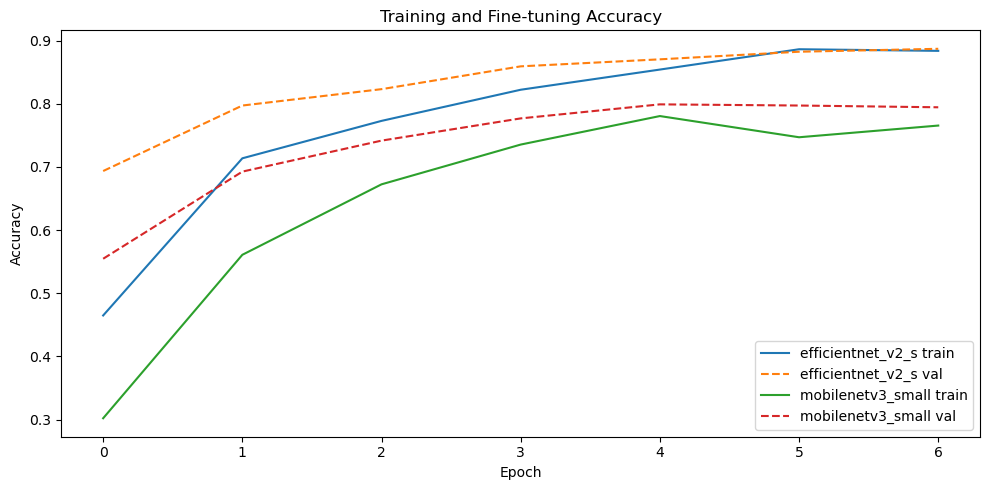

Saved model summary:


,model,best_model_path,final_model_path,final_train_accuracy,final_val_accuracy
0,efficientnet_v2_s,tea_training_state\efficientnet_v2_s\tea_model...,tea_training_state\efficientnet_v2_s\tea_model...,0.8838,0.8870
1,mobilenetv3_small,tea_training_state\mobilenetv3_small\tea_model...,tea_training_state\mobilenetv3_small\tea_model...,0.7655,0.7944


In [ ]:
# =========================
# 7. COMPARE SAVED RUNS
# =========================
# First, ensure the training state is loaded
if "analysis_state" not in globals():
    raise NameError(
        "analysis_state is not loaded. Run the 'LOAD TRAINING STATE' cell first."
    )


bundle_states = {}
bundle_names = []
for spec in MODEL_SPECS:
    model_name = spec["name"]
    bundle_path = Path("tea_training_state") / model_name / "analysis_state.joblib"

    if model_name == analysis_state["model_name"]:
        bundle_states[model_name] = analysis_state
        bundle_names.append(model_name)
        continue

    if not bundle_path.exists():
        print(f"⚠ Skipping {model_name}: missing saved bundle {bundle_path}")
        continue

    bundle_states[model_name] = joblib.load(bundle_path)
    bundle_names.append(model_name)

if not bundle_states:
    raise FileNotFoundError("No saved analysis bundles were found.")

summary_rows = []
plt.figure(figsize=(10, 5))
for model_name, state in bundle_states.items():
    acc = list(state.get("history", {}).get("accuracy", []))
    val_acc = list(state.get("history", {}).get("val_accuracy", []))
    acc += list(state.get("fine_tune_history", {}).get("accuracy", []))
    val_acc += list(state.get("fine_tune_history", {}).get("val_accuracy", []))

    if acc:
        plt.plot(acc, label=f"{model_name} train")
    if val_acc:
        plt.plot(val_acc, linestyle="--", label=f"{model_name} val")

    summary_rows.append(
        {
            "model": model_name,
            "best_model_path": state["best_model_path"],
            "final_model_path": state["final_model_path"],
            "final_train_accuracy": round(float(acc[-1]), 4) if acc else None,
            "final_val_accuracy": round(float(val_acc[-1]), 4) if val_acc else None,
        }
    )

plt.title("Training and Fine-tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows)
print("Saved model summary:")
display(summary_df)

In [45]:
# =========================
# 8. EXPORT THE ACTIVE ANALYSIS MODEL
# =========================
export_dir = Path("tea_training_state") / analysis_state["model_name"]
export_dir.mkdir(parents=True, exist_ok=True)

# Save in native Keras format (recommended over H5)
active_model_keras = export_dir / f"{analysis_state['model_name']}_export.keras"
model.save(active_model_keras)
print(f"Saved Keras model to: {active_model_keras}")

Saved Keras model to: tea_training_state\efficientnet_v2_s\efficientnet_v2_s_export.keras


In [46]:
# =========================
# 9. CONVERT ACTIVE MODEL TO TFLITE
# =========================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
tflite_path = (
    Path("tea_training_state")
    / analysis_state["model_name"]
    / f"{analysis_state['model_name']}.tflite"
)
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved TFLite model to: {tflite_path}")

INFO:tensorflow:Assets written to: C:\Users\deept\AppData\Local\Temp\tmpzra3kddy\assets


INFO:tensorflow:Assets written to: C:\Users\deept\AppData\Local\Temp\tmpzra3kddy\assets


Saved artifact at 'C:\Users\deept\AppData\Local\Temp\tmpzra3kddy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  1925090057808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090058576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090059152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090059920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090060496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090058768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090058960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090060304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090060880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925090061456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  192

Overall validation metrics:


,metric,value
0,accuracy,0.8870
1,precision (macro),0.8890
2,recall (macro),0.8870
3,f1-score (macro),0.8862


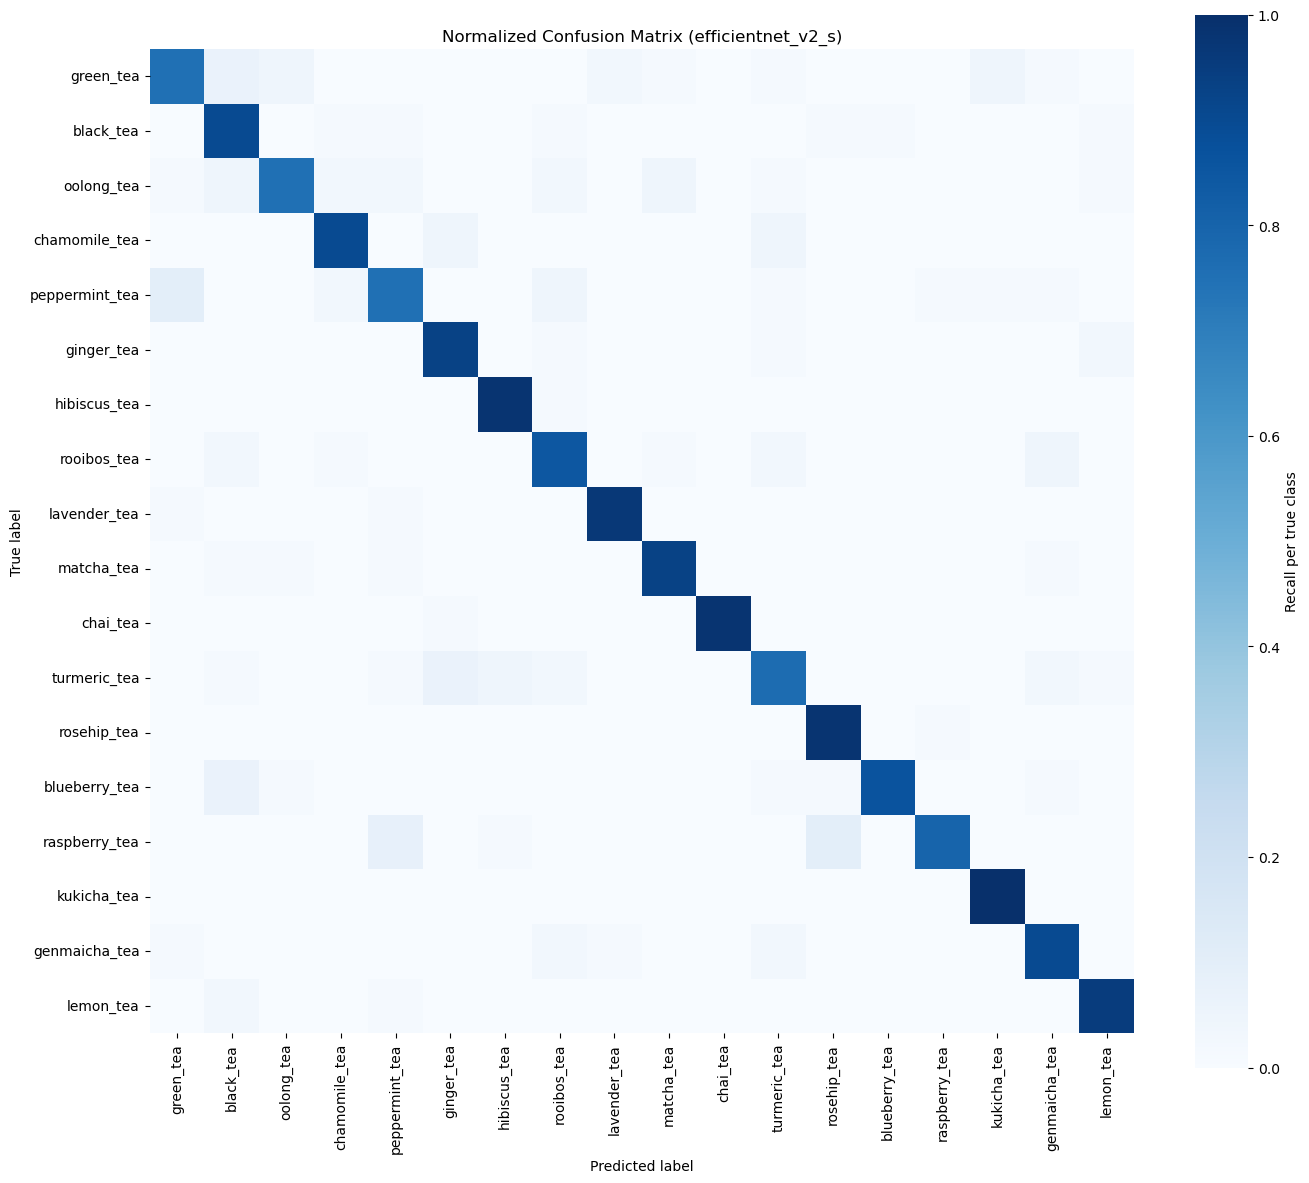

Per-class performance (lowest recall first):


,class,support,recall,most_confused_with,confused_count
0,green_tea,60,0.7500,black_tea,4
2,oolong_tea,60,0.7500,black_tea,3
4,peppermint_tea,60,0.7500,green_tea,6
11,turmeric_tea,60,0.7667,ginger_tea,4
14,raspberry_tea,60,0.8000,rosehip_tea,6
7,rooibos_tea,60,0.8500,genmaicha_tea,3
13,blueberry_tea,60,0.8667,black_tea,4
3,chamomile_tea,60,0.9000,ginger_tea,3
1,black_tea,60,0.9000,chamomile_tea,1
16,genmaicha_tea,60,0.9000,rooibos_tea,2


Top 15 confusion pairs:


,true_class,pred_class,count
61,raspberry_tea,rosehip_tea,6
23,peppermint_tea,green_tea,6
59,raspberry_tea,peppermint_tea,5
0,green_tea,black_tea,4
54,blueberry_tea,black_tea,4
48,turmeric_tea,ginger_tea,4
1,green_tea,oolong_tea,3
22,chamomile_tea,turmeric_tea,3
25,peppermint_tea,rooibos_tea,3
5,green_tea,kukicha_tea,3


In [47]:
# =========================
# 10. CONFUSION MATRIX + TOP CONFUSIONS FOR ACTIVE MODEL
# =========================
# Collect true labels in validation order
active_val_ds = val_ds

y_true = []
for _, labels_batch in active_val_ds:
    y_true.extend(labels_batch.numpy().tolist())
y_true = np.array(y_true, dtype=np.int32)

# Predict classes
y_prob = model.predict(active_val_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Confusion matrix
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

# Overall validation metrics
sample_count = cm.sum()
accuracy = np.trace(cm) / sample_count if sample_count > 0 else 0.0
precision_per_class = np.divide(
    np.diag(cm),
    cm.sum(axis=0),
    out=np.zeros(num_classes, dtype=float),
    where=cm.sum(axis=0) != 0,
)
recall_per_class = np.divide(
    np.diag(cm),
    cm.sum(axis=1),
    out=np.zeros(num_classes, dtype=float),
    where=cm.sum(axis=1) != 0,
)
f1_per_class = np.divide(
    2 * precision_per_class * recall_per_class,
    precision_per_class + recall_per_class,
    out=np.zeros(num_classes, dtype=float),
    where=(precision_per_class + recall_per_class) != 0,
)

metrics_df = pd.DataFrame(
    [
        {"metric": "accuracy", "value": round(float(accuracy), 4)},
        {
            "metric": "precision (macro)",
            "value": round(float(precision_per_class.mean()), 4),
        },
        {"metric": "recall (macro)", "value": round(float(recall_per_class.mean()), 4)},
        {"metric": "f1-score (macro)", "value": round(float(f1_per_class.mean()), 4)},
    ]
)

print("Overall validation metrics:")
display(metrics_df)

# Plot normalized confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Recall per true class"},
)
plt.title(f"Normalized Confusion Matrix ({analysis_state['model_name']})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class recall and strongest confusion target
rows = []
for i, true_name in enumerate(class_names):
    total = int(cm[i].sum())
    correct = int(cm[i, i])
    recall = (correct / total) if total > 0 else 0.0

    row_wo_diag = cm[i].copy()
    row_wo_diag[i] = 0
    worst_j = int(np.argmax(row_wo_diag))
    worst_count = int(row_wo_diag[worst_j])

    rows.append(
        {
            "class": true_name,
            "support": total,
            "recall": round(recall, 4),
            "most_confused_with": class_names[worst_j],
            "confused_count": worst_count,
        }
    )

per_class_df = pd.DataFrame(rows).sort_values(by="recall")
print("Per-class performance (lowest recall first):")
display(per_class_df)

# Global top confusion pairs (excluding diagonal)
pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(cm[i, j])))

pairs_df = pd.DataFrame(pairs, columns=["true_class", "pred_class", "count"])
pairs_df = pairs_df.sort_values(by="count", ascending=False).head(15)

print("Top 15 confusion pairs:")
display(pairs_df)

In [48]:
# =========================
# 11. COMPUTE METRICS FOR ALL MODELS
# =========================
# Load all saved models and compute comprehensive metrics for comparison


def compute_model_metrics(model_path, val_ds, num_classes, class_names):
    """Load model and compute all metrics."""
    if not Path(model_path).exists():
        return None

    loaded_model = tf.keras.models.load_model(model_path)

    # Collect true labels
    y_true = []
    for _, labels_batch in val_ds:
        y_true.extend(labels_batch.numpy().tolist())
    y_true = np.array(y_true, dtype=np.int32)

    # Predict
    y_prob = loaded_model.predict(val_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Confusion matrix
    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

    # Overall accuracy
    accuracy = np.trace(cm) / cm.sum() if cm.sum() > 0 else 0.0

    # Precision, Recall, F1 per class
    precision_per_class = np.divide(
        np.diag(cm),
        cm.sum(axis=0),
        out=np.zeros(num_classes, dtype=float),
        where=cm.sum(axis=0) != 0,
    )
    recall_per_class = np.divide(
        np.diag(cm),
        cm.sum(axis=1),
        out=np.zeros(num_classes, dtype=float),
        where=cm.sum(axis=1) != 0,
    )
    f1_per_class = np.divide(
        2 * precision_per_class * recall_per_class,
        precision_per_class + recall_per_class,
        out=np.zeros(num_classes, dtype=float),
        where=(precision_per_class + recall_per_class) != 0,
    )

    return {
        "cm": cm,
        "accuracy": accuracy,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "precision_macro": precision_per_class.mean(),
        "recall_macro": recall_per_class.mean(),
        "f1_macro": f1_per_class.mean(),
    }


# Load metrics for all models
all_model_metrics = {}
print("Computing metrics for all models...\n")

for spec in MODEL_SPECS:
    model_name = spec["name"]
    state_path = Path("tea_training_state") / model_name / "analysis_state.joblib"

    if not state_path.exists():
        print(f"⚠ Skipping {model_name}: state file not found")
        continue

    # Load state
    state = joblib.load(state_path)

    # Rebuild validation dataset
    img_size = tuple(state["img_size"])
    batch_size = state["batch_size"]
    val_paths_local = state["val_paths"]
    val_labels_local = state["val_labels"]

    def load_and_preprocess_local(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32)
        return img, tf.cast(label, tf.int32)

    val_ds_local = tf.data.Dataset.from_tensor_slices(
        (val_paths_local, val_labels_local)
    )
    val_ds_local = val_ds_local.map(
        load_and_preprocess_local, num_parallel_calls=AUTOTUNE
    )
    val_ds_local = val_ds_local.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

    # Load best model
    model_path = state["best_model_path"]
    metrics = compute_model_metrics(model_path, val_ds_local, num_classes, class_names)

    if metrics:
        all_model_metrics[model_name] = metrics
        print(f"✓ {model_name}: Accuracy={metrics['accuracy']:.4f}")
    else:
        print(f"✗ {model_name}: Could not compute metrics")

print("\n✓ Metrics computed for all available models")

Computing metrics for all models...

✓ efficientnet_v2_s: Accuracy=0.8870
✓ mobilenetv3_small: Accuracy=0.7991

✓ Metrics computed for all available models


In [49]:
# =========================
# 12. COMPREHENSIVE COMPARISON TABLE
# =========================
# Create a detailed comparison table with all metrics

comparison_rows = []
for model_name, metrics in all_model_metrics.items():
    comparison_rows.append(
        {
            "Model": model_name,
            "Accuracy": round(float(metrics["accuracy"]), 4),
            "Precision (Macro)": round(float(metrics["precision_macro"]), 4),
            "Recall (Macro)": round(float(metrics["recall_macro"]), 4),
            "F1-Score (Macro)": round(float(metrics["f1_macro"]), 4),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 80)
print("OVERALL MODEL COMPARISON (Macro-averaged metrics)")
print("=" * 80)
display(comparison_df)

# Per-class comparison (average across all models)
print("\n" + "=" * 80)
print("PER-CLASS METRICS SUMMARY (Averaged across all models)")
print("=" * 80)

per_class_summary = []
for i, class_name in enumerate(class_names):
    class_precisions = [
        metrics["precision_per_class"][i] for metrics in all_model_metrics.values()
    ]
    class_recalls = [
        metrics["recall_per_class"][i] for metrics in all_model_metrics.values()
    ]
    class_f1s = [metrics["f1_per_class"][i] for metrics in all_model_metrics.values()]

    per_class_summary.append(
        {
            "Class": class_name,
            "Avg Precision": round(float(np.mean(class_precisions)), 4),
            "Avg Recall": round(float(np.mean(class_recalls)), 4),
            "Avg F1": round(float(np.mean(class_f1s)), 4),
            "Std Precision": round(float(np.std(class_precisions)), 4),
            "Std Recall": round(float(np.std(class_recalls)), 4),
            "Std F1": round(float(np.std(class_f1s)), 4),
        }
    )

per_class_df = pd.DataFrame(per_class_summary)
display(per_class_df)

OVERALL MODEL COMPARISON (Macro-averaged metrics)


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,efficientnet_v2_s,0.8870,0.8890,0.8870,0.8862
1,mobilenetv3_small,0.7991,0.8103,0.7991,0.7980



PER-CLASS METRICS SUMMARY (Averaged across all models)


,Class,Avg Precision,Avg Recall,Avg F1,Std Precision,Std Recall,Std F1
0,green_tea,0.7867,0.6833,0.7311,0.0467,0.0667,0.0584
1,black_tea,0.7712,0.8083,0.7861,0.0106,0.0917,0.0383
2,oolong_tea,0.8582,0.7083,0.7761,0.0418,0.0417,0.0421
3,chamomile_tea,0.8532,0.8667,0.8598,0.0468,0.0333,0.0402
4,peppermint_tea,0.7254,0.7167,0.7207,0.0641,0.0333,0.0485
5,ginger_tea,0.8375,0.8333,0.8342,0.0375,0.1000,0.0690
6,hibiscus_tea,0.9415,0.9333,0.9366,0.0050,0.0500,0.0228
7,rooibos_tea,0.6985,0.8167,0.7503,0.1110,0.0333,0.0789
8,lavender_tea,0.8968,0.9750,0.9332,0.0540,0.0083,0.0255
9,matcha_tea,0.9173,0.9250,0.9211,0.0007,0.0083,0.0045


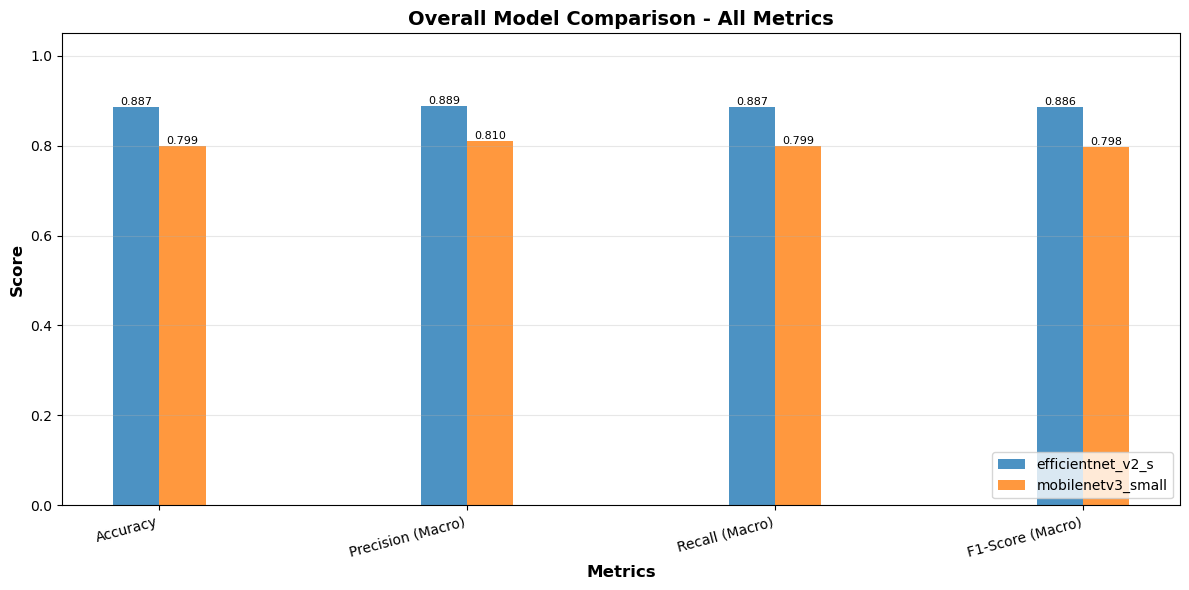

In [50]:
# =========================
# 13. VISUALIZATION 1: BAR CHART - OVERALL METRICS COMPARISON
# =========================

fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = [
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-Score (Macro)",
]
x = np.arange(len(metrics_to_plot))
width = 0.15

for idx, (model_name, row) in enumerate(comparison_df.iterrows()):
    values = [row[metric] for metric in metrics_to_plot]
    ax.bar(x + idx * width, values, width, label=row["Model"], alpha=0.8)

ax.set_xlabel("Metrics", fontsize=12, fontweight="bold")
ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title("Overall Model Comparison - All Metrics", fontsize=14, fontweight="bold")
ax.set_xticks(x + width * (len(comparison_df) - 1) / 2)
ax.set_xticklabels(metrics_to_plot, rotation=15, ha="right")
ax.legend(loc="lower right", fontsize=10)
ax.set_ylim([0, 1.05])
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()
plt.show()

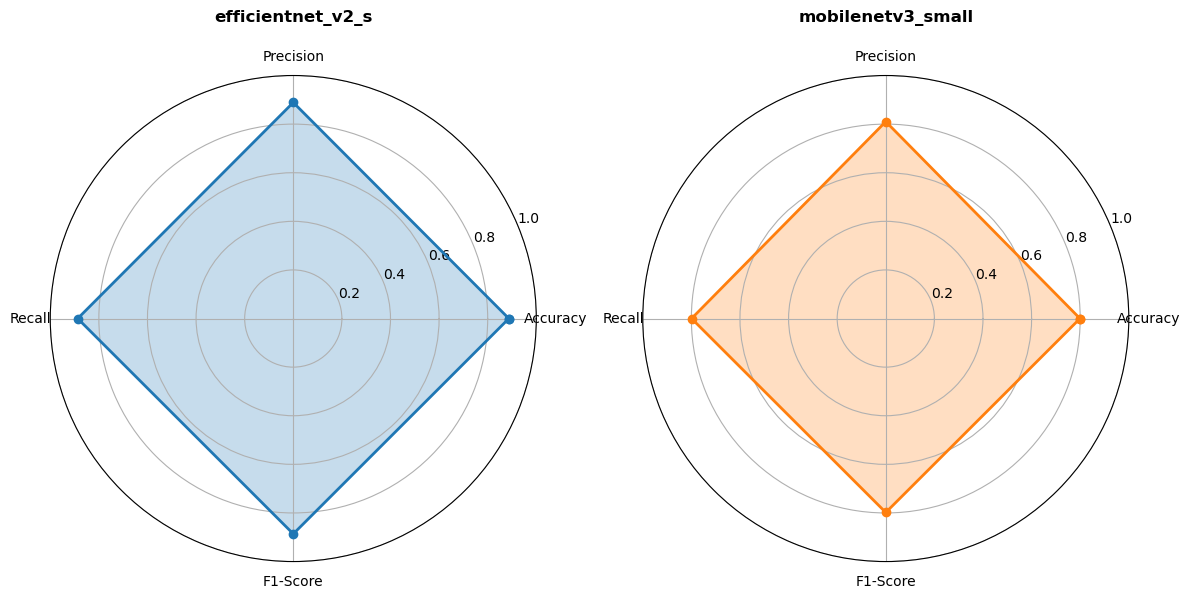

In [51]:
# =========================
# 14. VISUALIZATION 2: RADAR CHART - PER-MODEL PERFORMANCE
# =========================

from math import pi

num_models = len(all_model_metrics)
fig, axes = plt.subplots(
    1, num_models, figsize=(6 * num_models, 6), subplot_kw=dict(projection="polar")
)

# Handle single model case
if num_models == 1:
    axes = [axes]

categories = ["Accuracy", "Precision", "Recall", "F1-Score"]
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

for idx, (model_name, metrics) in enumerate(all_model_metrics.items()):
    values = [
        metrics["accuracy"],
        metrics["precision_macro"],
        metrics["recall_macro"],
        metrics["f1_macro"],
    ]
    values += values[:1]  # Complete the circle

    ax = axes[idx]
    ax.plot(angles, values, "o-", linewidth=2, label=model_name, color=f"C{idx}")
    ax.fill(angles, values, alpha=0.25, color=f"C{idx}")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(model_name, fontsize=12, fontweight="bold", pad=20)
    ax.grid(True)

plt.tight_layout()
plt.show()

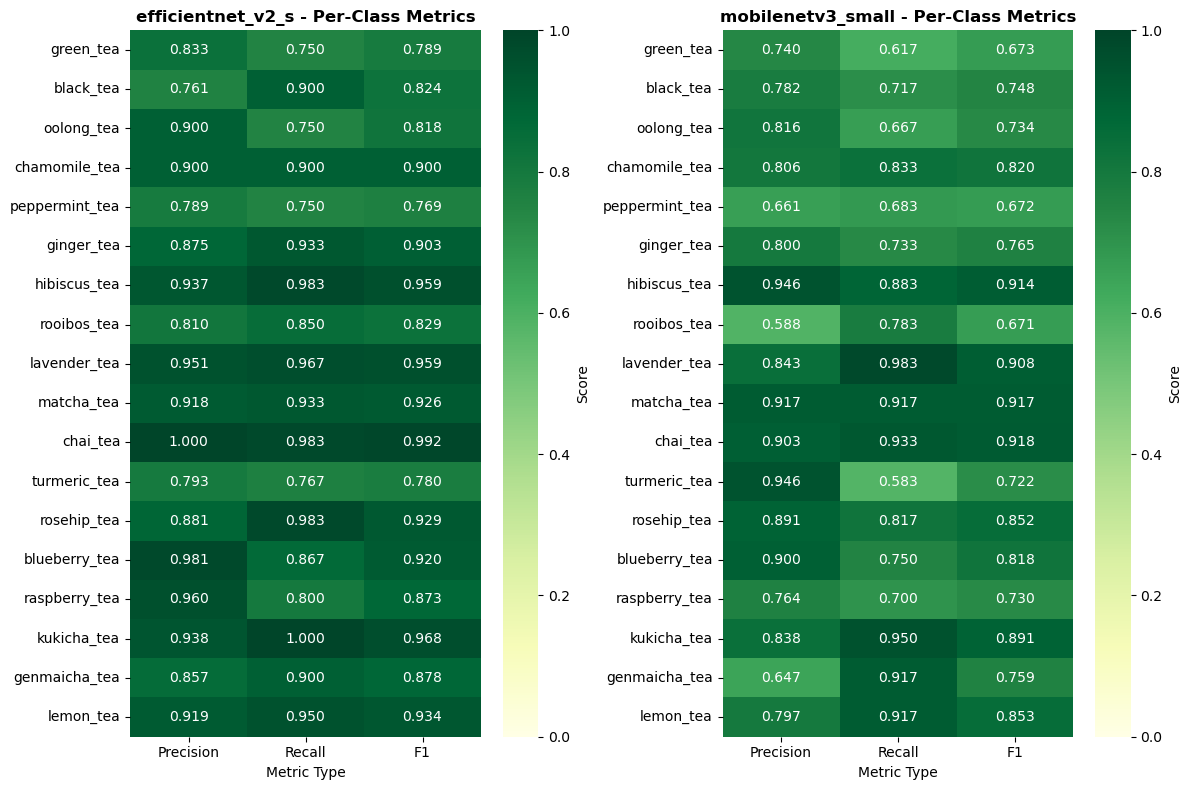

In [52]:
# =========================
# 15. VISUALIZATION 3: HEATMAPS - PER-CLASS F1 SCORES
# =========================

fig, axes = plt.subplots(
    1, len(all_model_metrics), figsize=(6 * len(all_model_metrics), 8)
)

# Handle single model case
if len(all_model_metrics) == 1:
    axes = [axes]

for idx, (model_name, metrics) in enumerate(all_model_metrics.items()):
    ax = axes[idx]

    # Create matrix with Precision, Recall, F1 for each class
    data_matrix = np.column_stack(
        [
            metrics["precision_per_class"],
            metrics["recall_per_class"],
            metrics["f1_per_class"],
        ]
    )

    sns.heatmap(
        data_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlGn",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Score"},
        xticklabels=["Precision", "Recall", "F1"],
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f"{model_name} - Per-Class Metrics", fontweight="bold")
    ax.set_xlabel("Metric Type")

plt.tight_layout()
plt.show()

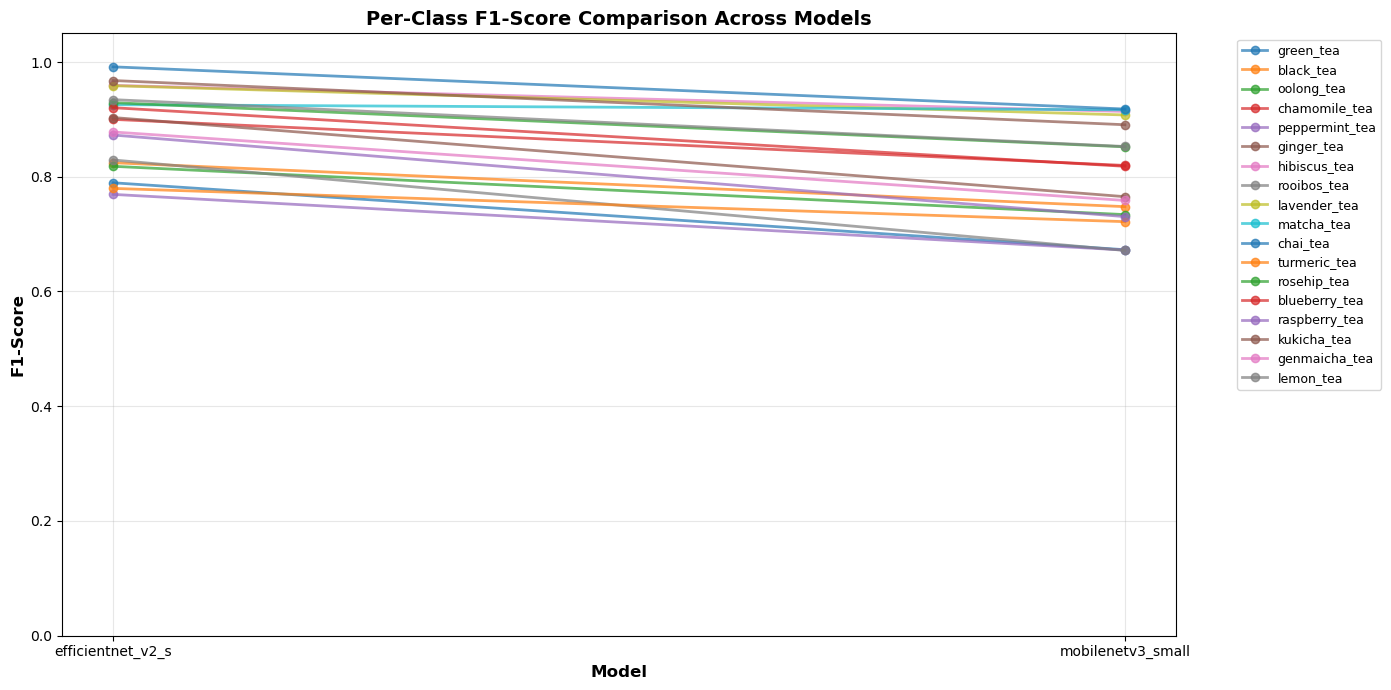

In [53]:
# =========================
# 16. VISUALIZATION 4: LINE CHART - PER-CLASS F1 ACROSS MODELS
# =========================

fig, ax = plt.subplots(figsize=(14, 7))

model_names_list = list(all_model_metrics.keys())

for class_idx, class_name in enumerate(class_names):
    f1_scores = [
        all_model_metrics[m]["f1_per_class"][class_idx] for m in model_names_list
    ]
    ax.plot(
        model_names_list,
        f1_scores,
        marker="o",
        linewidth=2,
        label=class_name,
        alpha=0.7,
    )

ax.set_xlabel("Model", fontsize=12, fontweight="bold")
ax.set_ylabel("F1-Score", fontsize=12, fontweight="bold")
ax.set_title(
    "Per-Class F1-Score Comparison Across Models", fontsize=14, fontweight="bold"
)
ax.legend(loc="best", bbox_to_anchor=(1.05, 1), ncol=1, fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

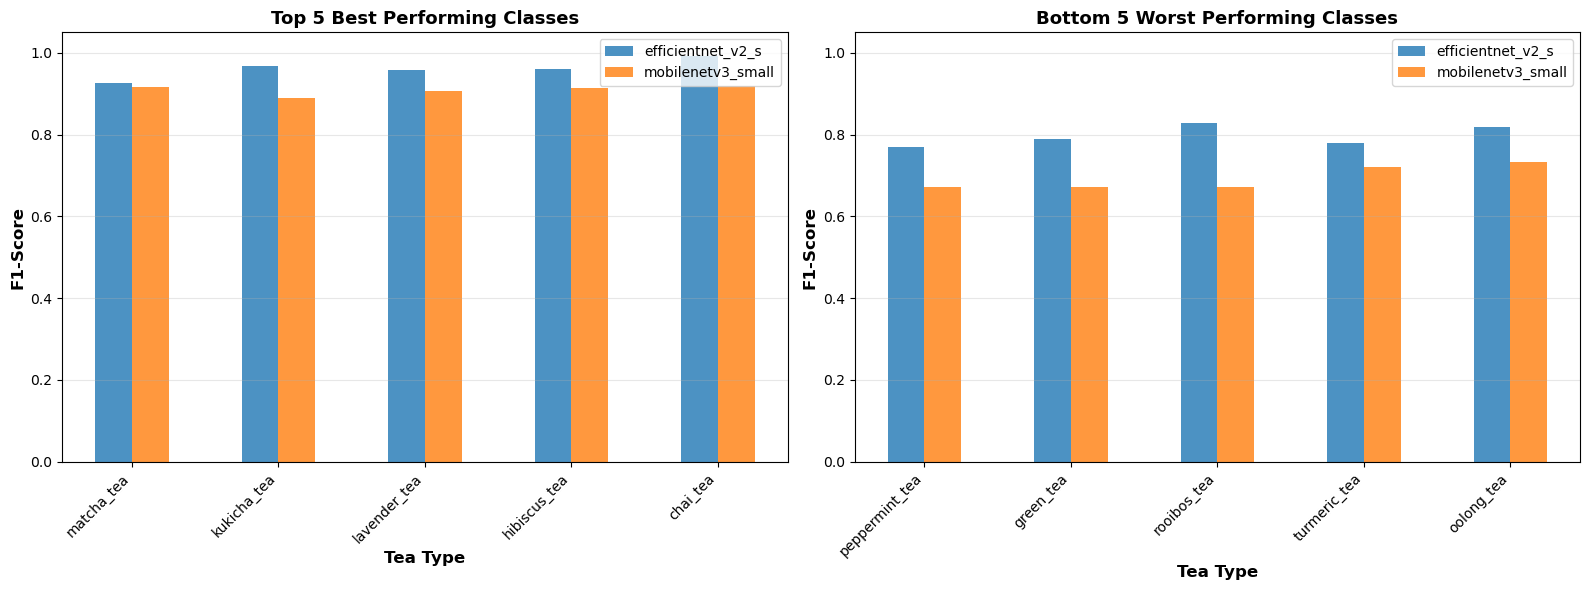

In [54]:
# =========================
# 17. VISUALIZATION 5: GROUPED BAR CHART - TOP/BOTTOM PERFORMING CLASSES
# =========================

# Show top and bottom 5 performing classes by F1 score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Compute average F1 per class across all models
avg_f1_per_class = []
for i, class_name in enumerate(class_names):
    avg_f1 = np.mean(
        [all_model_metrics[m]["f1_per_class"][i] for m in all_model_metrics.keys()]
    )
    avg_f1_per_class.append((class_name, avg_f1))

avg_f1_per_class.sort(key=lambda x: x[1])

# Top 5
top_5 = avg_f1_per_class[-5:]
top_classes = [x[0] for x in top_5]
top_f1 = [x[1] for x in top_5]

x_pos = np.arange(len(top_classes))
width = 0.25

for idx, model_name in enumerate(all_model_metrics.keys()):
    top_precision = [
        all_model_metrics[model_name]["precision_per_class"][class_names.index(c)]
        for c in top_classes
    ]
    top_recall = [
        all_model_metrics[model_name]["recall_per_class"][class_names.index(c)]
        for c in top_classes
    ]
    top_f1_model = [
        all_model_metrics[model_name]["f1_per_class"][class_names.index(c)]
        for c in top_classes
    ]

    ax1.bar(x_pos + idx * width, top_f1_model, width, label=model_name, alpha=0.8)

ax1.set_xlabel("Tea Type", fontsize=12, fontweight="bold")
ax1.set_ylabel("F1-Score", fontsize=12, fontweight="bold")
ax1.set_title("Top 5 Best Performing Classes", fontsize=13, fontweight="bold")
ax1.set_xticks(x_pos + width * (len(all_model_metrics) - 1) / 2)
ax1.set_xticklabels(top_classes, rotation=45, ha="right")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)
ax1.set_ylim([0, 1.05])

# Bottom 5
bottom_5 = avg_f1_per_class[:5]
bottom_classes = [x[0] for x in bottom_5]
bottom_f1 = [x[1] for x in bottom_5]

x_pos_bottom = np.arange(len(bottom_classes))

for idx, model_name in enumerate(all_model_metrics.keys()):
    bottom_f1_model = [
        all_model_metrics[model_name]["f1_per_class"][class_names.index(c)]
        for c in bottom_classes
    ]
    ax2.bar(
        x_pos_bottom + idx * width, bottom_f1_model, width, label=model_name, alpha=0.8
    )

ax2.set_xlabel("Tea Type", fontsize=12, fontweight="bold")
ax2.set_ylabel("F1-Score", fontsize=12, fontweight="bold")
ax2.set_title("Bottom 5 Worst Performing Classes", fontsize=13, fontweight="bold")
ax2.set_xticks(x_pos_bottom + width * (len(all_model_metrics) - 1) / 2)
ax2.set_xticklabels(bottom_classes, rotation=45, ha="right")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

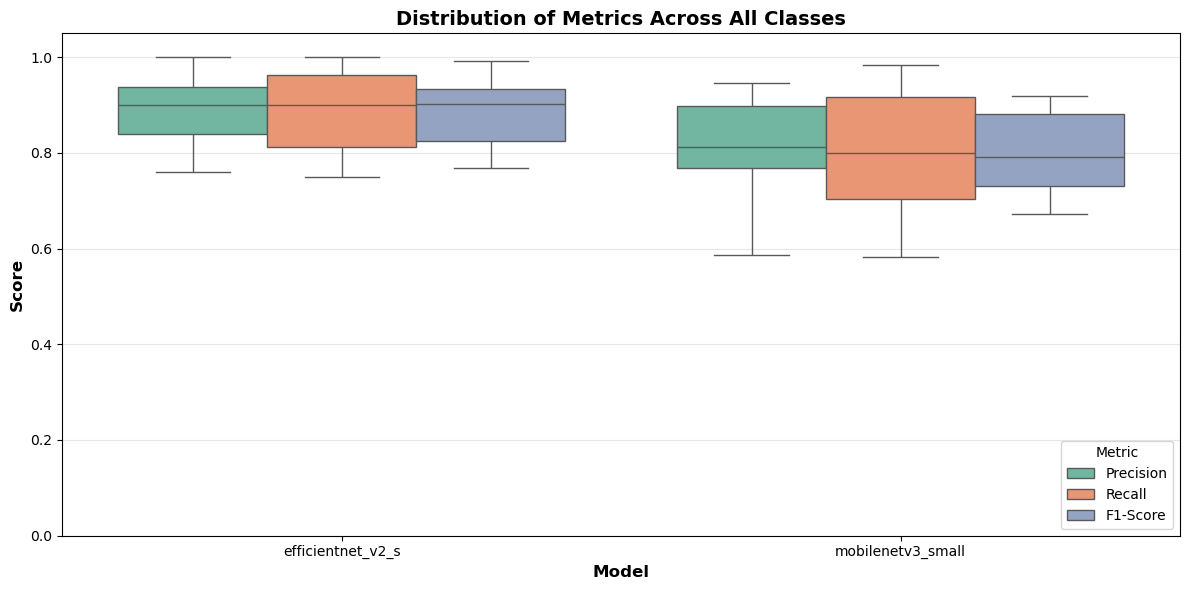

In [55]:
# =========================
# 18. VISUALIZATION 6: BOX PLOT - METRIC DISTRIBUTION
# =========================

# Prepare data for box plots
box_data = {"Model": [], "Metric": [], "Value": []}

for model_name, metrics in all_model_metrics.items():
    # Precision
    for p in metrics["precision_per_class"]:
        box_data["Model"].append(model_name)
        box_data["Metric"].append("Precision")
        box_data["Value"].append(p)
    # Recall
    for r in metrics["recall_per_class"]:
        box_data["Model"].append(model_name)
        box_data["Metric"].append("Recall")
        box_data["Value"].append(r)
    # F1
    for f in metrics["f1_per_class"]:
        box_data["Model"].append(model_name)
        box_data["Metric"].append("F1-Score")
        box_data["Value"].append(f)

box_df = pd.DataFrame(box_data)

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=box_df, x="Model", y="Value", hue="Metric", ax=ax, palette="Set2")

ax.set_xlabel("Model", fontsize=12, fontweight="bold")
ax.set_ylabel("Score", fontsize=12, fontweight="bold")
ax.set_title(
    "Distribution of Metrics Across All Classes", fontsize=14, fontweight="bold"
)
ax.set_ylim([0, 1.05])
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Metric", loc="lower right")

plt.tight_layout()
plt.show()

In [56]:
# =========================
# 19. DETAILED COMPARISON EXPORT TABLE
# =========================
# Create a comprehensive export table with all per-class metrics

detailed_export = []

for model_name, metrics in all_model_metrics.items():
    for class_idx, class_name in enumerate(class_names):
        detailed_export.append(
            {
                "Model": model_name,
                "Class": class_name,
                "Precision": round(float(metrics["precision_per_class"][class_idx]), 4),
                "Recall": round(float(metrics["recall_per_class"][class_idx]), 4),
                "F1-Score": round(float(metrics["f1_per_class"][class_idx]), 4),
            }
        )

detailed_df = pd.DataFrame(detailed_export)

print("=" * 100)
print("DETAILED PER-CLASS METRICS FOR ALL MODELS")
print("=" * 100)
display(detailed_df)

# Export to CSV for external analysis
export_path = Path("tea_training_state") / "model_comparison_detailed.csv"
detailed_df.to_csv(export_path, index=False)
print(f"\n✓ Exported detailed comparison to: {export_path}")

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

stats_summary = []
for model_name, metrics in all_model_metrics.items():
    all_f1 = metrics["f1_per_class"]
    stats_summary.append(
        {
            "Model": model_name,
            "Accuracy": round(float(metrics["accuracy"]), 4),
            "Mean Precision": round(float(metrics["precision_macro"]), 4),
            "Std Precision": round(float(np.std(metrics["precision_per_class"])), 4),
            "Mean Recall": round(float(metrics["recall_macro"]), 4),
            "Std Recall": round(float(np.std(metrics["recall_per_class"])), 4),
            "Mean F1": round(float(metrics["f1_macro"]), 4),
            "Std F1": round(float(np.std(all_f1)), 4),
            "Min F1": round(float(np.min(all_f1)), 4),
            "Max F1": round(float(np.max(all_f1)), 4),
        }
    )

stats_df = pd.DataFrame(stats_summary)
display(stats_df)

# Export statistics
stats_path = Path("tea_training_state") / "model_comparison_statistics.csv"
stats_df.to_csv(stats_path, index=False)
print(f"\n✓ Exported statistics to: {stats_path}")

DETAILED PER-CLASS METRICS FOR ALL MODELS


,Model,Class,Precision,Recall,F1-Score
0,efficientnet_v2_s,green_tea,0.8333,0.7500,0.7895
1,efficientnet_v2_s,black_tea,0.7606,0.9000,0.8244
2,efficientnet_v2_s,oolong_tea,0.9000,0.7500,0.8182
3,efficientnet_v2_s,chamomile_tea,0.9000,0.9000,0.9000
4,efficientnet_v2_s,peppermint_tea,0.7895,0.7500,0.7692
5,efficientnet_v2_s,ginger_tea,0.8750,0.9333,0.9032
6,efficientnet_v2_s,hibiscus_tea,0.9365,0.9833,0.9593
7,efficientnet_v2_s,rooibos_tea,0.8095,0.8500,0.8293
8,efficientnet_v2_s,lavender_tea,0.9508,0.9667,0.9587
9,efficientnet_v2_s,matcha_tea,0.9180,0.9333,0.9256



✓ Exported detailed comparison to: tea_training_state\model_comparison_detailed.csv

SUMMARY STATISTICS


,Model,Accuracy,Mean Precision,Std Precision,Mean Recall,Std Recall,Mean F1,Std F1,Min F1,Max F1
0,efficientnet_v2_s,0.8870,0.8890,0.0677,0.8870,0.0869,0.8862,0.0675,0.7692,0.9916
1,mobilenetv3_small,0.7991,0.8103,0.1000,0.7991,0.1200,0.7980,0.0871,0.6714,0.9180



✓ Exported statistics to: tea_training_state\model_comparison_statistics.csv


In [57]:
# =========================
# 20. MODEL RECOMMENDATION & INSIGHTS
# =========================

print("=" * 80)
print("MODEL PERFORMANCE ANALYSIS & RECOMMENDATIONS")
print("=" * 80)

# Find best overall model
if "comparison_df" not in globals() or comparison_df.empty:
    print("No comparison results available — run metric computation first.")
else:
    best_accuracy_idx = comparison_df["Accuracy"].idxmax()
    best_accuracy_model = comparison_df.loc[best_accuracy_idx, "Model"]
    best_accuracy_score = comparison_df.loc[best_accuracy_idx, "Accuracy"]

    best_f1_idx = comparison_df["F1-Score (Macro)"].idxmax()
    best_f1_model = comparison_df.loc[best_f1_idx, "Model"]
    best_f1_score = comparison_df.loc[best_f1_idx, "F1-Score (Macro)"]

    print(f"\n📊 BEST OVERALL ACCURACY: {best_accuracy_model}")
    print(f"   Accuracy: {best_accuracy_score:.4f}")

    print(f"\n🎯 BEST OVERALL F1-SCORE: {best_f1_model}")
    print(f"   Macro F1: {best_f1_score:.4f}")

    # Class-specific performance
    print("\n\n🏆 CLASS-SPECIFIC INSIGHTS:")
    for i, class_name in enumerate(class_names):
        class_f1_scores = [
            all_model_metrics[m]["f1_per_class"][i] for m in all_model_metrics.keys()
        ]
        best_model_idx = np.argmax(class_f1_scores)
        best_model_name = list(all_model_metrics.keys())[best_model_idx]
        best_f1_value = class_f1_scores[best_model_idx]

        emoji = "✓" if best_f1_value > 0.85 else "⚠" if best_f1_value > 0.70 else "✗"
        print(
            f"  {emoji} {class_name:20s} → Best: {best_model_name:20s} (F1: {best_f1_value:.4f})"
        )

    # Consistency analysis
    print("\n\n📈 MODEL CONSISTENCY:")
    for model_name, metrics in all_model_metrics.items():
        f1_std = float(np.std(metrics["f1_per_class"]))
        f1_mean = float(np.mean(metrics["f1_per_class"]))
        consistency = "High" if f1_std < 0.1 else "Medium" if f1_std < 0.15 else "Low"
        print(
            f"  {model_name:20s}: Mean F1={f1_mean:.4f}, Std Dev={f1_std:.4f} ({consistency})"
        )

print("\n" + "=" * 80)

MODEL PERFORMANCE ANALYSIS & RECOMMENDATIONS

📊 BEST OVERALL ACCURACY: efficientnet_v2_s
   Accuracy: 0.8870

🎯 BEST OVERALL F1-SCORE: efficientnet_v2_s
   Macro F1: 0.8862


🏆 CLASS-SPECIFIC INSIGHTS:
  ⚠ green_tea            → Best: efficientnet_v2_s    (F1: 0.7895)
  ⚠ black_tea            → Best: efficientnet_v2_s    (F1: 0.8244)
  ⚠ oolong_tea           → Best: efficientnet_v2_s    (F1: 0.8182)
  ✓ chamomile_tea        → Best: efficientnet_v2_s    (F1: 0.9000)
  ⚠ peppermint_tea       → Best: efficientnet_v2_s    (F1: 0.7692)
  ✓ ginger_tea           → Best: efficientnet_v2_s    (F1: 0.9032)
  ✓ hibiscus_tea         → Best: efficientnet_v2_s    (F1: 0.9593)
  ⚠ rooibos_tea          → Best: efficientnet_v2_s    (F1: 0.8293)
  ✓ lavender_tea         → Best: efficientnet_v2_s    (F1: 0.9587)
  ✓ matcha_tea           → Best: efficientnet_v2_s    (F1: 0.9256)
  ✓ chai_tea             → Best: efficientnet_v2_s    (F1: 0.9916)
  ⚠ turmeric_tea         → Best: efficientnet_v2_s    (F1: 0.